In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/tracker_full_df.csv')
df.head()


,Unnamed: 0.17,Unnamed: 0.16,Unnamed: 0.15,Unnamed: 0.14,Unnamed: 0.13,Unnamed: 0.12,Unnamed: 0.11,Unnamed: 0.10,Unnamed: 0.9,Unnamed: 0.8,...,before_shell_id,after_shell_id,before_nu,before_mu,before_energy,after_nu,after_mu,after_energy,line_absorb_id,line_emit_id
0,0,0,0,0,0,0,0,0,0,0,...,-1,0,9.582424e+14,0.913997,0.000103,9.582424e+14,0.913997,0.000103,-1,-1
1,1,1,1,1,1,1,1,1,1,1,...,0,1,9.582424e+14,0.920910,0.000103,9.582424e+14,0.920910,0.000103,-1,-1
2,2,2,2,2,2,2,2,2,2,2,...,1,1,9.582424e+14,0.925052,0.000103,9.334155e+14,0.271002,0.000101,-1,-1
3,3,3,3,3,3,3,3,3,3,3,...,1,2,9.334155e+14,0.311018,0.000101,9.334155e+14,0.311018,0.000101,-1,-1
4,4,4,4,4,4,4,4,4,4,4,...,2,3,9.334155e+14,0.401694,0.000101,9.334155e+14,0.401694,0.000101,-1,-1


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [ ]:
print(f"tracker_full_df shape: {df.shape}")
print(f"\nInteraction type counts:\n{df['interaction_type'].value_counts()}\n")
print(f"Columns: {list(df.columns)}")


tracker_full_df shape: (209999, 33)

Interaction type counts:
interaction_type
BOUNDARY       193876
LINE             8454
ESCATTERING      7669
Name: count, dtype: int64

Columns: ['Unnamed: 0.17', 'Unnamed: 0.16', 'Unnamed: 0.15', 'Unnamed: 0.14', 'Unnamed: 0.13', 'Unnamed: 0.12', 'Unnamed: 0.11', 'Unnamed: 0.10', 'Unnamed: 0.9', 'Unnamed: 0.8', 'Unnamed: 0.7', 'Unnamed: 0.6', 'Unnamed: 0.5', 'Unnamed: 0.4', 'Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'packet_id', 'event_id', 'interaction_type', 'status', 'radius', 'before_shell_id', 'after_shell_id', 'before_nu', 'before_mu', 'before_energy', 'after_nu', 'after_mu', 'after_energy', 'line_absorb_id', 'line_emit_id']


In [ ]:
def select_best_packet(df, required_types=("LINE", "ESCATTERING")):
    """
    Select the packet with the most diverse physical interactions
    that also escaped the simulation.

    Parameters
    ----------
    df : pd.DataFrame
        Full tracker dataframe containing all packets and events.
    required_types : tuple, optional
        Interaction types to consider as physical.
        Default is ("LINE", "ESCATTERING").

    Returns
    -------
    int
        Packet ID with the most diverse interaction types that escaped.
    """
    escaped_packets = df[
        df["interaction_type"] == "ESCAPE"
    ]["packet_id"].unique()

    if len(escaped_packets) == 0:
        print("Warning: no ESCAPE events found, using all packets.")
        escaped_packets = df["packet_id"].unique()

    physical = df[
        (df["interaction_type"].isin(required_types)) &
        (df["packet_id"].isin(escaped_packets))
    ]

    if len(physical) == 0:
        raise ValueError("No physical interactions found for escaped packets.")

    diverse = physical.groupby("packet_id")["interaction_type"].nunique()
    mixed = diverse[diverse > 1]

    if len(mixed) > 0:
        counts = physical[physical["packet_id"].isin(mixed.index)] \
                    .groupby("packet_id")["interaction_type"].count()
        best = counts.idxmax()
    else:
        best = physical.groupby("packet_id")["interaction_type"].count().idxmax()

    return best


best_packet_id = select_best_packet(df)
print(f"Selected packet ID: {best_packet_id}")


Selected packet ID: 1625


In [ ]:
packet_df = df[df["packet_id"] == best_packet_id].copy()
print(f"Total events for this packet (including BOUNDARY): {len(packet_df)}")
print(f"Final interaction (escape check): {packet_df.iloc[-1]['interaction_type']}")

non_boundary = packet_df[
    packet_df["interaction_type"] != "BOUNDARY"
].copy().reset_index(drop=True)

print(f"Physical (non-boundary) interactions: {len(non_boundary)}")
print(f"Interaction types present: {non_boundary['interaction_type'].unique()}")
print()
print(non_boundary[
    ["event_id", "interaction_type", "before_shell_id",
     "after_shell_id", "before_nu", "after_nu"]
].to_string())


Total events for this packet (including BOUNDARY): 63
Final interaction (escape check): BOUNDARY
Physical (non-boundary) interactions: 36
Interaction types present: ['ESCATTERING' 'LINE']

    event_id interaction_type  before_shell_id  after_shell_id     before_nu      after_nu
0          5      ESCATTERING                4               4  7.102884e+14  6.970547e+14
1         10             LINE                8               8  6.970547e+14  4.553011e+15
2         11             LINE                8               8  4.553011e+15  4.501106e+15
3         12             LINE                8               8  4.501106e+15  3.477114e+15
4         17      ESCATTERING                4               4  3.477114e+15  3.472425e+15
5         20             LINE                2               2  3.472425e+15  3.580768e+15
6         21             LINE                2               2  3.580768e+15  3.522393e+15
7         22             LINE                2               2  3.522393e+15  3.738

In [ ]:
def plot_packet(
    df,
    packet_id=None,
    interaction_types=None,
    start_shell=None,
    end_shell=None,
    out_path=None,
    show=True,
):
    """
    Plot the interaction history of a single escaped packet
    from the tracker dataframe.

    Filters out BOUNDARY interactions and shows shell location and
    frequency shift across physical interaction events.
    Only considers packets that escaped the simulation.

    Parameters
    ----------
    df : pd.DataFrame
        Full tracker dataframe containing all packets and events.
    packet_id : int, optional
        Specific packet ID to plot. If None, auto-selects the packet
        with the most diverse physical interactions that escaped.
    interaction_types : list of str, optional
        Subset of interaction types to display.
        Default is ["LINE", "ESCATTERING"].
        Example: ["LINE"] to show only line interactions.
    start_shell : int, optional
        Only include events where before_shell_id >= start_shell.
    end_shell : int, optional
        Only include events where before_shell_id <= end_shell.
    out_path : str, optional
        File path to save the plot image. If None, plot is not saved.
    show : bool, optional
        Whether to display the plot inline. Default is True.
        Set to False during testing to suppress visual output.

    Returns
    -------
    matplotlib.figure.Figure or None
        The generated figure object, or None if no data matches filters.

    Examples
    --------
    >>> fig = plot_packet(df)
    >>> fig = plot_packet(df, packet_id=42, interaction_types=["LINE"])
    >>> fig = plot_packet(df, start_shell=2, end_shell=5,
    ...                   out_path="packet_plot.png")
    >>> fig = plot_packet(df, show=False)  # suppress display for testing
    """
    if interaction_types is None:
        interaction_types = ["LINE", "ESCATTERING"]

    if packet_id is None:
        packet_id = select_best_packet(df, required_types=interaction_types)

    packet_df = df[df["packet_id"] == packet_id].copy()
    data = packet_df[
        packet_df["interaction_type"].isin(interaction_types)
    ].copy().reset_index(drop=True)

    if start_shell is not None:
        data = data[data["before_shell_id"] >= start_shell]
    if end_shell is not None:
        data = data[data["before_shell_id"] <= end_shell]

    data = data.reset_index(drop=True)

    if len(data) == 0:
        print("No interactions found for the given filters.")
        return None

    color_map = {"LINE": "#e74c3c", "ESCATTERING": "#3498db"}
    colors = data["interaction_type"].map(color_map).fillna("#95a5a6")

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(
        f"Packet {packet_id} — Interaction History (escaped)\n"
        f"Types: {interaction_types}  |  "
        f"Shells: {start_shell or 'all'} → {end_shell or 'all'}",
        fontsize=13, fontweight="bold"
    )

    # Top plot — shell location
    axes[0].scatter(
        data["event_id"], data["before_shell_id"],
        c=colors, s=120, edgecolors="k", linewidths=0.5, zorder=3
    )
    axes[0].plot(
        data["event_id"], data["before_shell_id"],
        color="gray", alpha=0.4
    )
    axes[0].set_xlabel("Event step")
    axes[0].set_ylabel("Shell ID")
    axes[0].set_title("Shell location at each interaction")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(handles=[
        mpatches.Patch(color=v, label=k)
        for k, v in color_map.items()
        if k in interaction_types
    ])

    # Bottom plot — frequency shift
    axes[1].plot(
        data["event_id"], data["before_nu"],
        marker="o", label="Before ν"
    )
    axes[1].plot(
        data["event_id"], data["after_nu"],
        marker="s", linestyle="--", label="After ν"
    )
    axes[1].set_xlabel("Event step")
    axes[1].set_ylabel("Frequency ν (Hz)")
    axes[1].set_title("Frequency shift across interactions")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()

    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Plot saved → {out_path}")

    if show:
        plt.show()

    plt.close(fig)
    return fig


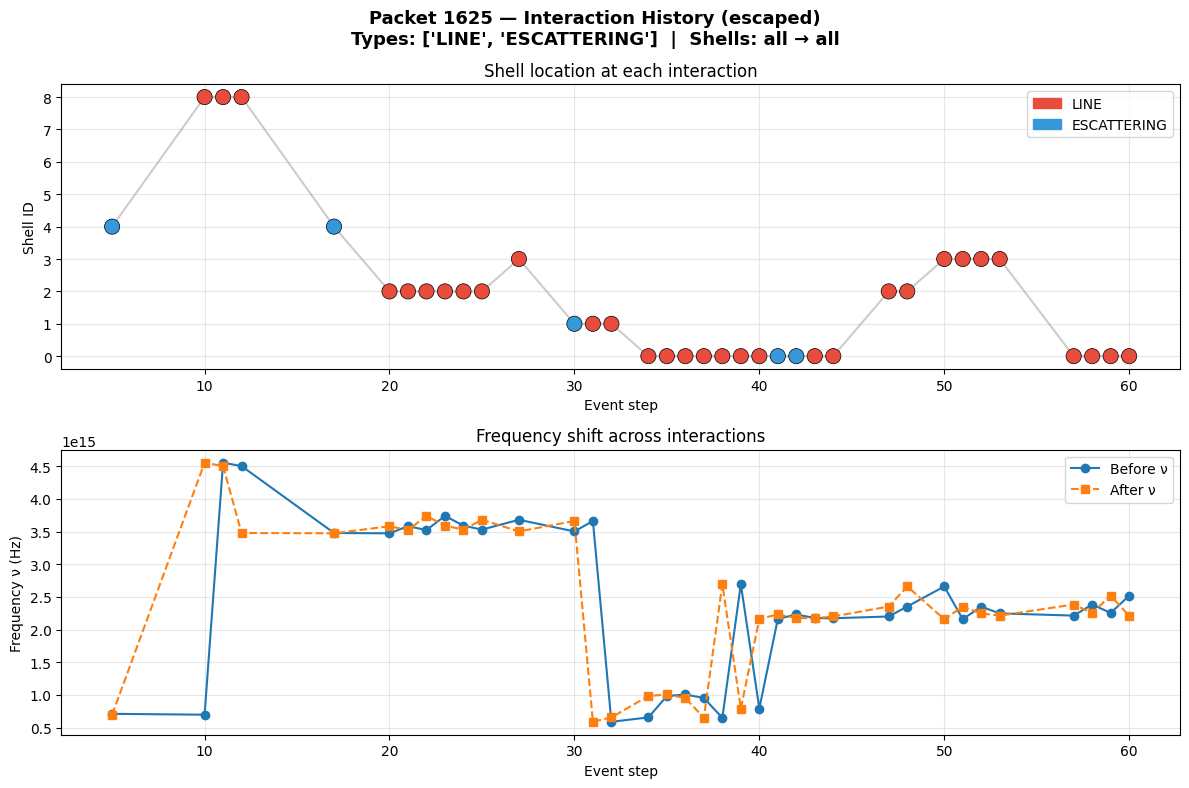

In [ ]:
# --- default: auto-select best escaped packet, all interaction types ---
fig = plot_packet(df)


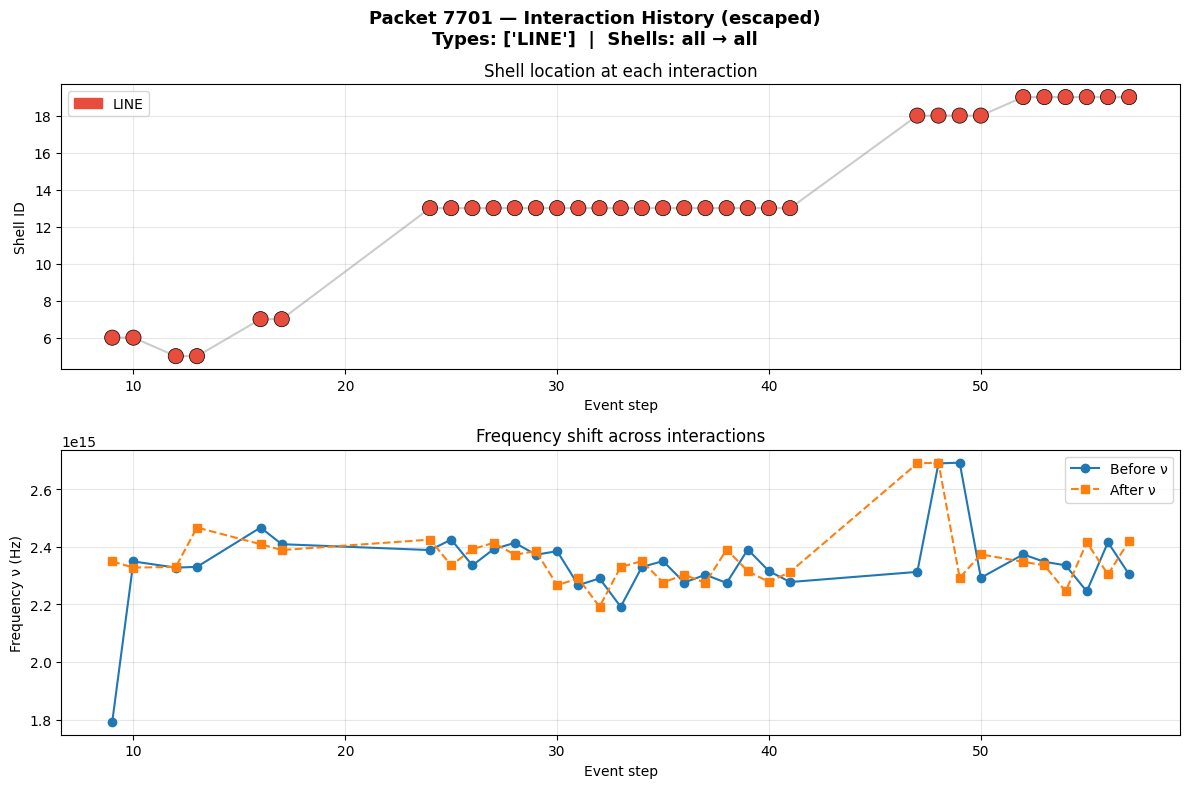

In [ ]:
# --- custom: only LINE interactions ---
fig = plot_packet(df, interaction_types=["LINE"])


Plot saved → /content/drive/My Drive/Colab Notebooks/packet_plot.png


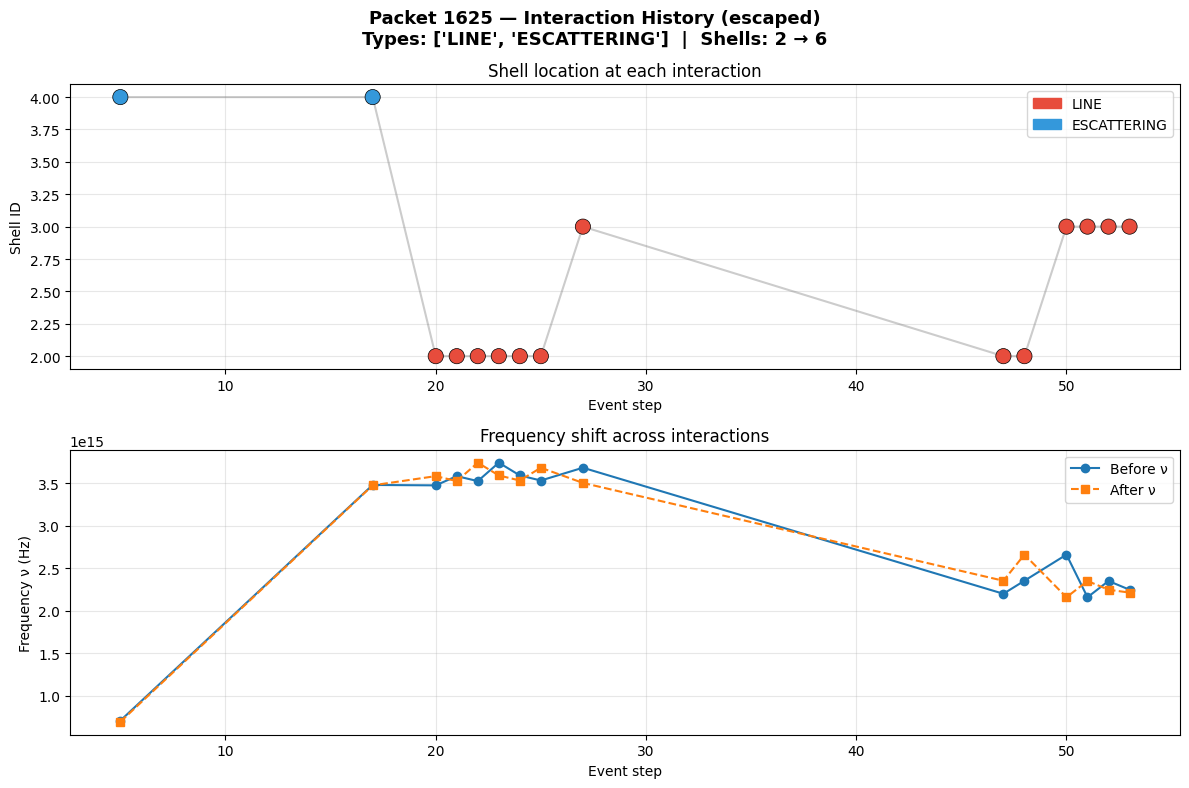

In [ ]:
# --- custom: specific packet, shell range, save to Drive ---
out_path = '/content/drive/My Drive/Colab Notebooks/packet_plot.png'
fig = plot_packet(
    df,
    packet_id=best_packet_id,
    interaction_types=["LINE", "ESCATTERING"],
    start_shell=2,
    end_shell=6,
    out_path=out_path
)


In [ ]:
def run_tests(df):
    """Basic tests for select_best_packet and plot_packet."""
    print("Running tests...\n")

    has_escape = "ESCAPE" in df["interaction_type"].values

    # Test 1: select_best_packet returns a valid packet_id
    pid = select_best_packet(df)
    assert pid in df["packet_id"].values, "FAIL: packet_id not in dataframe"
    print(f"PASS — select_best_packet returns valid id: {pid}")

    # Test 2: select_best_packet works with custom required_types
    pid_line = select_best_packet(df, required_types=("LINE",))
    assert pid_line in df["packet_id"].values, \
        "FAIL: packet_id not found for custom required_types"
    print(f"PASS — select_best_packet works with required_types=('LINE',): id={pid_line}")

    # Test 3: escape check — only if ESCAPE events exist in data
    if has_escape:
        escaped = df[
            (df["packet_id"] == pid) &
            (df["interaction_type"] == "ESCAPE")
        ]
        assert len(escaped) > 0, "FAIL: selected packet did not escape"
        print("PASS — selected packet has ESCAPE event")
    else:
        print("SKIP — no ESCAPE events in dataset, escape check skipped")

    # Test 4: selected packet has physical interactions
    physical = df[
        (df["packet_id"] == pid) &
        (df["interaction_type"].isin(["LINE", "ESCATTERING"]))
    ]
    assert len(physical) > 0, "FAIL: no physical interactions found"
    print(f"PASS — packet has interaction types: {physical['interaction_type'].unique()}")

    # Test 5: plot_packet runs without error, no visual output
    fig = plot_packet(df, packet_id=pid, out_path=None, show=False)
    assert fig is not None, "FAIL: plot_packet returned None"
    plt.close("all")
    print("PASS — plot_packet runs without error")

    # Test 6: interaction_types filter actually filters correctly
    fig_line = plot_packet(df, packet_id=pid, interaction_types=["LINE"], show=False)
    plt.close("all")
    line_only = df[
        (df["packet_id"] == pid) &
        (df["interaction_type"] == "LINE")
    ]
    assert len(line_only) > 0 or fig_line is None, "FAIL: LINE filter broken"
    print("PASS — interaction_types filter works correctly")

    # Test 7: shell filter works with actual data range
    shell_min = int(df["before_shell_id"].min())
    shell_max = int(df["before_shell_id"].max())
    fig_shell = plot_packet(
        df, packet_id=pid,
        start_shell=shell_min,
        end_shell=shell_max,
        show=False
    )
    plt.close("all")
    assert fig_shell is not None, "FAIL: shell filter returned None"
    print(f"PASS — shell range filter works (shells {shell_min}→{shell_max})")

    # Test 8: returns None when filters match nothing
    fig_empty = plot_packet(
        df, packet_id=pid,
        start_shell=99999,
        end_shell=99999,
        show=False
    )
    plt.close("all")
    assert fig_empty is None, "FAIL: should return None for impossible shell range"
    print("PASS — returns None correctly when no data matches filters")

    print("\nAll tests passed.")

run_tests(df)

Running tests...

PASS — select_best_packet returns valid id: 1625
PASS — select_best_packet works with required_types=('LINE',): id=7701
SKIP — no ESCAPE events in dataset, escape check skipped
PASS — packet has interaction types: ['ESCATTERING' 'LINE']
PASS — plot_packet runs without error
PASS — interaction_types filter works correctly
PASS — shell range filter works (shells -1→19)
No interactions found for the given filters.
PASS — returns None correctly when no data matches filters

All tests passed.
